Exploratory Data Analysis

In [25]:
#Importing the libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency


In [16]:
#Reading the dataset
data = pd.read_csv('s:/Projects/Customer Churn ML Model and API/data/raw/WA_Fn-UseC_-Telco-Customer-Churn.csv')

In [17]:
print(data.head())

   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL             No  ...               No   
1                No             DSL            Yes  ...              Yes   
2                No             DSL            Yes  ...               No   
3  No phone service             DSL            Yes  ...              Yes   
4                No     Fiber optic             No  ...               No   

  TechSupport StreamingTV StreamingMovies        Contract Pape

In [18]:
#Printing all the necessary information about the dataset
print(data.info())
print("------------------------------")
print(data.describe())
print("------------------------------")
print(data.shape)
print("------------------------------")
print(data.dtypes)
print("------------------------------")


<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [19]:
#Checking for missing values
print(data.isnull().sum())

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


In [20]:
# Calculate churn distribution
churn_counts = data['Churn'].value_counts()
churn_percentage = data['Churn'].value_counts(normalize=True) * 100

print("Churn Distribution:")
print(churn_counts)
print("\nChurn Percentage:")
print(churn_percentage)

Churn Distribution:
Churn
No     5174
Yes    1869
Name: count, dtype: int64

Churn Percentage:
Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64


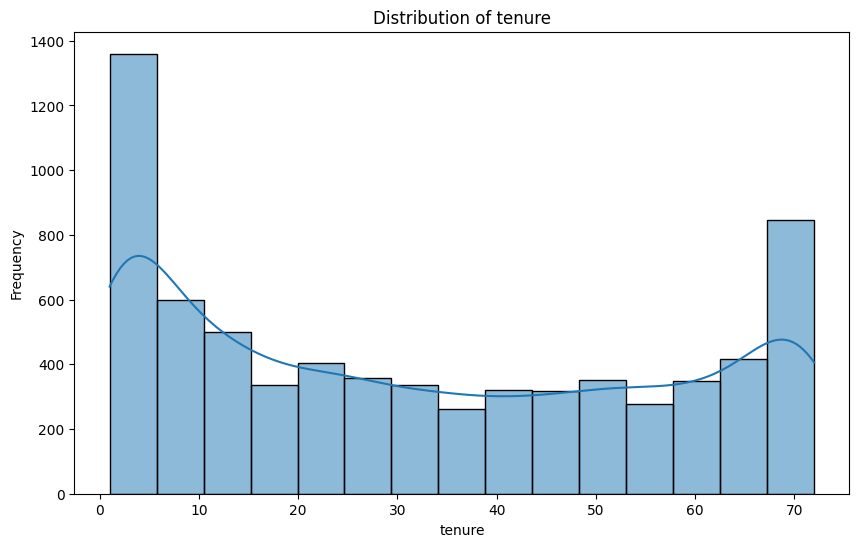

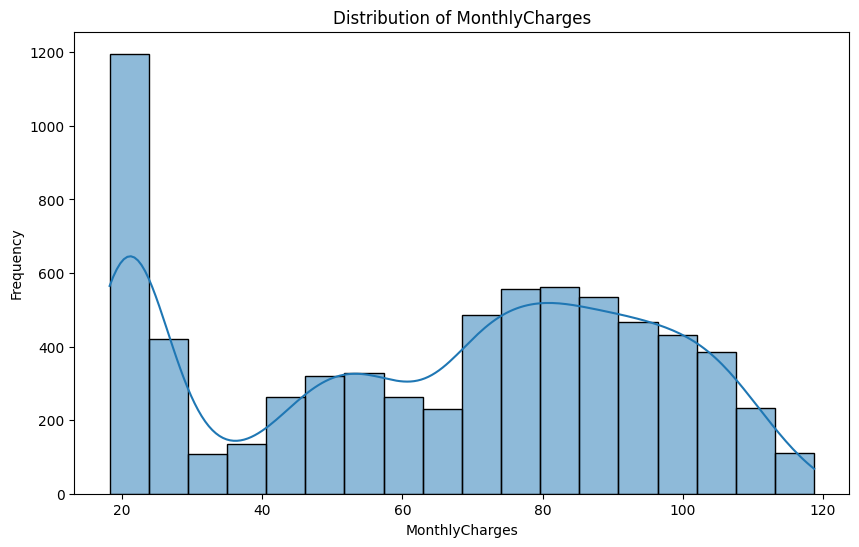

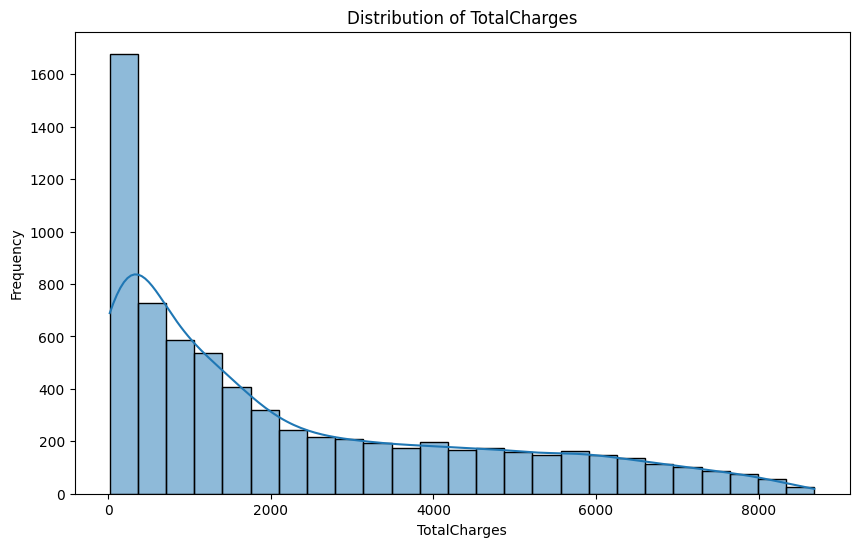

In [21]:
#Plotting numerical features

data['TotalCharges'] = pd.to_numeric(data['TotalCharges'], errors='coerce')
data.dropna(subset=['TotalCharges'], inplace=True)

num_features = ['tenure', 'MonthlyCharges', 'TotalCharges']

for feature in num_features:
    plt.figure(figsize=(10, 6))
    sns.histplot(data[feature], kde=True)
    plt.title(f'Distribution of {feature}')
    plt.xlabel(feature)
    plt.ylabel('Frequency')
    plt.show()



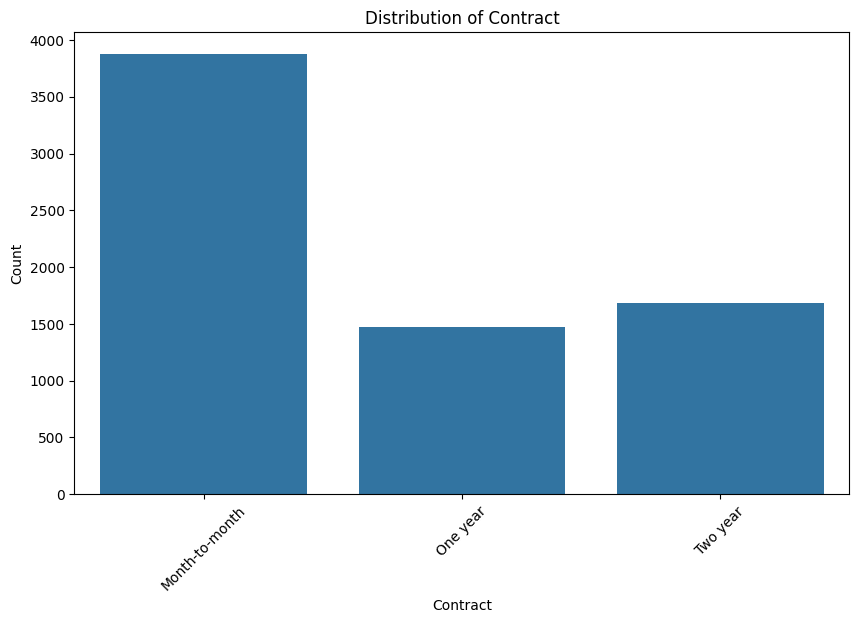

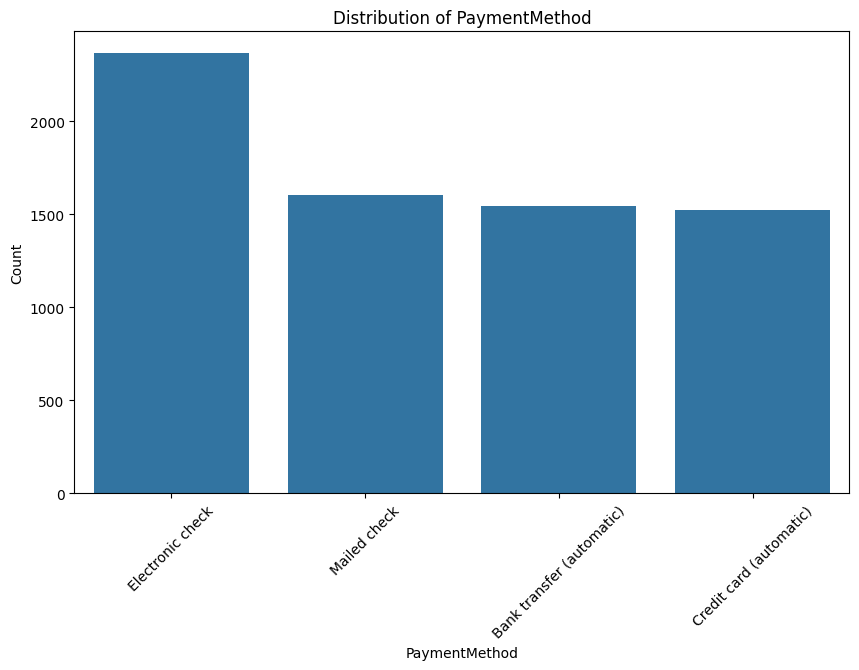

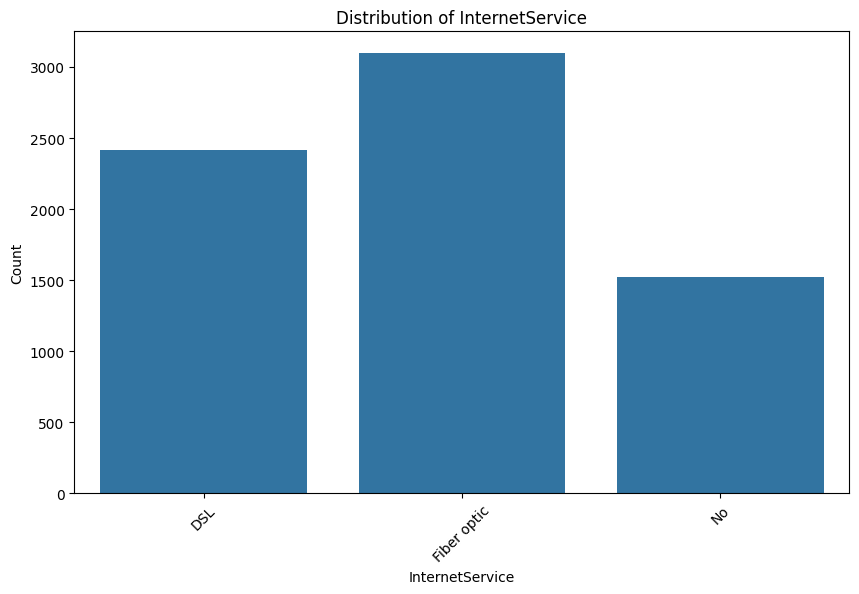

In [22]:
#Categorical features distribution

cat_features = ['Contract', 'PaymentMethod', 'InternetService']

for feature in cat_features:
    plt.figure(figsize=(10, 6))
    sns.countplot(x=data[feature])
    plt.title(f'Distribution of {feature}')
    plt.xlabel(feature)
    plt.ylabel('Count')
    plt.xticks(rotation=45)
    plt.show()

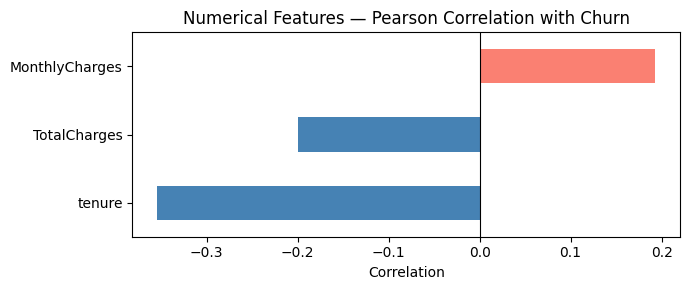

tenure           -0.354049
TotalCharges     -0.199484
MonthlyCharges    0.192858
dtype: float64


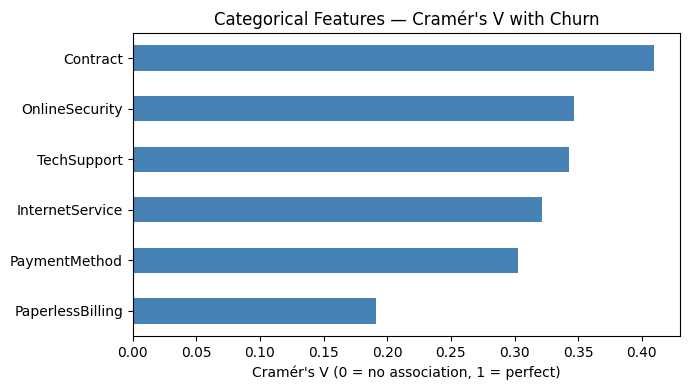

Contract            0.409560
OnlineSecurity      0.346992
TechSupport         0.342506
InternetService     0.321909
PaymentMethod       0.302960
PaperlessBilling    0.191127
dtype: float64


In [26]:
#Corelation with churn

#Correlation between numerical features and churn
data['Churn_binary'] = (data['Churn'] == 'Yes').astype(int)

num_features = ['tenure', 'MonthlyCharges', 'TotalCharges']
correlations = data[num_features].corrwith(data['Churn_binary']).sort_values()

correlations.plot(kind='barh', color=['salmon' if v > 0 else 'steelblue' for v in correlations], figsize=(7, 3))
plt.axvline(0, color='black', linewidth=0.8)
plt.title('Numerical Features — Pearson Correlation with Churn')
plt.xlabel('Correlation')
plt.tight_layout()
plt.show()
print(correlations)

#Correlation between categorical features and churn
def cramers_v(col):
    ct = pd.crosstab(data[col], data['Churn'])
    chi2 = chi2_contingency(ct)[0]
    n = ct.values.sum()
    return np.sqrt(chi2 / (n * (min(ct.shape) - 1)))

cat_features = ['Contract', 'PaymentMethod', 'InternetService',
                'OnlineSecurity', 'TechSupport', 'PaperlessBilling']

cat_corr = pd.Series({col: cramers_v(col) for col in cat_features}).sort_values()

cat_corr.plot(kind='barh', color='steelblue', figsize=(7, 4))
plt.title("Categorical Features — Cramér's V with Churn")
plt.xlabel("Cramér's V (0 = no association, 1 = perfect)")
plt.tight_layout()
plt.show()
print(cat_corr.sort_values(ascending=False))